# Credit Card Fraud Detection




## 1. Import Required Libraries




In [ ]:
# Data handling
import pandas as pd
import numpy as np

# Visualization
import matplotlib.pyplot as plt
import seaborn as sns

# Preprocessing
from sklearn.preprocessing import StandardScaler

# Train-test split
from sklearn.model_selection import train_test_split

# Handling class imbalance
from imblearn.over_sampling import RandomOverSampler, SMOTE
from imblearn.under_sampling import RandomUnderSampler

# Models
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier

# Evaluation
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score, f1_score,
    roc_auc_score, roc_curve, confusion_matrix, classification_report
)

# Saving the model
import joblib

# Warnings
import warnings
warnings.filterwarnings("ignore")

# Plot style
sns.set_style("whitegrid")
plt.rcParams["figure.figsize"] = (8, 5)

# For reproducibility
RANDOM_STATE = 42
np.random.seed(RANDOM_STATE)

print("All libraries imported successfully.")

All libraries imported successfully.


## 2. Load the Dataset




In [ ]:
df = pd.read_csv("creditcard.csv")
print("Dataset loaded successfully.")
print(f"Dataset shape: {df.shape}")

Dataset loaded successfully.
Dataset shape: (284807, 31)


## 3. Display First Five and Last Five Records



In [ ]:
# First five records
df.head()

,Time,V1,V2,V3,V4,V5,V6,V7,V8,V9,...,V21,V22,V23,V24,V25,V26,V27,V28,Amount,Class
0,0.0,-1.359807,-0.072781,2.536347,1.378155,-0.338321,0.462388,0.239599,0.098698,0.363787,...,-0.018307,0.277838,-0.110474,0.066928,0.128539,-0.189115,0.133558,-0.021053,149.62,0
1,0.0,1.191857,0.266151,0.166480,0.448154,0.060018,-0.082361,-0.078803,0.085102,-0.255425,...,-0.225775,-0.638672,0.101288,-0.339846,0.167170,0.125895,-0.008983,0.014724,2.69,0
2,1.0,-1.358354,-1.340163,1.773209,0.379780,-0.503198,1.800499,0.791461,0.247676,-1.514654,...,0.247998,0.771679,0.909412,-0.689281,-0.327642,-0.139097,-0.055353,-0.059752,378.66,0
3,1.0,-0.966272,-0.185226,1.792993,-0.863291,-0.010309,1.247203,0.237609,0.377436,-1.387024,...,-0.108300,0.005274,-0.190321,-1.175575,0.647376,-0.221929,0.062723,0.061458,123.50,0
4,2.0,-1.158233,0.877737,1.548718,0.403034,-0.407193,0.095921,0.592941,-0.270533,0.817739,...,-0.009431,0.798278,-0.137458,0.141267,-0.206010,0.502292,0.219422,0.215153,69.99,0


In [ ]:
# Last five records
df.tail()

,Time,V1,V2,V3,V4,V5,V6,V7,V8,V9,...,V21,V22,V23,V24,V25,V26,V27,V28,Amount,Class
284802,172786.0,-11.881118,10.071785,-9.834783,-2.066656,-5.364473,-2.606837,-4.918215,7.305334,1.914428,...,0.213454,0.111864,1.014480,-0.509348,1.436807,0.250034,0.943651,0.823731,0.77,0
284803,172787.0,-0.732789,-0.055080,2.035030,-0.738589,0.868229,1.058415,0.024330,0.294869,0.584800,...,0.214205,0.924384,0.012463,-1.016226,-0.606624,-0.395255,0.068472,-0.053527,24.79,0
284804,172788.0,1.919565,-0.301254,-3.249640,-0.557828,2.630515,3.031260,-0.296827,0.708417,0.432454,...,0.232045,0.578229,-0.037501,0.640134,0.265745,-0.087371,0.004455,-0.026561,67.88,0
284805,172788.0,-0.240440,0.530483,0.702510,0.689799,-0.377961,0.623708,-0.686180,0.679145,0.392087,...,0.265245,0.800049,-0.163298,0.123205,-0.569159,0.546668,0.108821,0.104533,10.00,0
284806,172792.0,-0.533413,-0.189733,0.703337,-0.506271,-0.012546,-0.649617,1.577006,-0.414650,0.486180,...,0.261057,0.643078,0.376777,0.008797,-0.473649,-0.818267,-0.002415,0.013649,217.00,0


## 4. Explore the Dataset




In [ ]:
# Shape of the dataset
print("Shape of the dataset (rows, columns):", df.shape)

Shape of the dataset (rows, columns): (284807, 31)


In [ ]:
# Column names
print("Columns in the dataset:")
print(df.columns.tolist())

Columns in the dataset:
['Time', 'V1', 'V2', 'V3', 'V4', 'V5', 'V6', 'V7', 'V8', 'V9', 'V10', 'V11', 'V12', 'V13', 'V14', 'V15', 'V16', 'V17', 'V18', 'V19', 'V20', 'V21', 'V22', 'V23', 'V24', 'V25', 'V26', 'V27', 'V28', 'Amount', 'Class']


In [ ]:
# Data types
df.dtypes

,0
Time,float64
V1,float64
V2,float64
V3,float64
V4,float64
V5,float64
V6,float64
V7,float64
V8,float64
V9,float64


In [ ]:
# Missing values in each column
missing_values = df.isnull().sum()
print("Total missing values in the dataset:", missing_values.sum())
missing_values[missing_values > 0]

Total missing values in the dataset: 0


,0


In [ ]:
# Duplicate records
duplicate_count = df.duplicated().sum()
print(f"Number of duplicate records: {duplicate_count}")

Number of duplicate records: 1081


In [ ]:
# Statistical summary of numerical columns
df.describe()

,Time,V1,V2,V3,V4,V5,V6,V7,V8,V9,...,V21,V22,V23,V24,V25,V26,V27,V28,Amount,Class
count,284807.000000,2.848070e+05,2.848070e+05,2.848070e+05,2.848070e+05,2.848070e+05,2.848070e+05,2.848070e+05,2.848070e+05,2.848070e+05,...,2.848070e+05,2.848070e+05,2.848070e+05,2.848070e+05,2.848070e+05,2.848070e+05,2.848070e+05,2.848070e+05,284807.000000,284807.000000
mean,94813.859575,1.168375e-15,3.416908e-16,-1.379537e-15,2.074095e-15,9.604066e-16,1.487313e-15,-5.556467e-16,1.213481e-16,-2.406331e-15,...,1.654067e-16,-3.568593e-16,2.578648e-16,4.473266e-15,5.340915e-16,1.683437e-15,-3.660091e-16,-1.227390e-16,88.349619,0.001727
std,47488.145955,1.958696e+00,1.651309e+00,1.516255e+00,1.415869e+00,1.380247e+00,1.332271e+00,1.237094e+00,1.194353e+00,1.098632e+00,...,7.345240e-01,7.257016e-01,6.244603e-01,6.056471e-01,5.212781e-01,4.822270e-01,4.036325e-01,3.300833e-01,250.120109,0.041527
min,0.000000,-5.640751e+01,-7.271573e+01,-4.832559e+01,-5.683171e+00,-1.137433e+02,-2.616051e+01,-4.355724e+01,-7.321672e+01,-1.343407e+01,...,-3.483038e+01,-1.093314e+01,-4.480774e+01,-2.836627e+00,-1.029540e+01,-2.604551e+00,-2.256568e+01,-1.543008e+01,0.000000,0.000000
25%,54201.500000,-9.203734e-01,-5.985499e-01,-8.903648e-01,-8.486401e-01,-6.915971e-01,-7.682956e-01,-5.540759e-01,-2.086297e-01,-6.430976e-01,...,-2.283949e-01,-5.423504e-01,-1.618463e-01,-3.545861e-01,-3.171451e-01,-3.269839e-01,-7.083953e-02,-5.295979e-02,5.600000,0.000000
50%,84692.000000,1.810880e-02,6.548556e-02,1.798463e-01,-1.984653e-02,-5.433583e-02,-2.741871e-01,4.010308e-02,2.235804e-02,-5.142873e-02,...,-2.945017e-02,6.781943e-03,-1.119293e-02,4.097606e-02,1.659350e-02,-5.213911e-02,1.342146e-03,1.124383e-02,22.000000,0.000000
75%,139320.500000,1.315642e+00,8.037239e-01,1.027196e+00,7.433413e-01,6.119264e-01,3.985649e-01,5.704361e-01,3.273459e-01,5.971390e-01,...,1.863772e-01,5.285536e-01,1.476421e-01,4.395266e-01,3.507156e-01,2.409522e-01,9.104512e-02,7.827995e-02,77.165000,0.000000
max,172792.000000,2.454930e+00,2.205773e+01,9.382558e+00,1.687534e+01,3.480167e+01,7.330163e+01,1.205895e+02,2.000721e+01,1.559499e+01,...,2.720284e+01,1.050309e+01,2.252841e+01,4.584549e+00,7.519589e+00,3.517346e+00,3.161220e+01,3.384781e+01,25691.160000,1.000000


In [ ]:
# Class distribution
class_counts = df["Class"].value_counts()
class_percentage = df["Class"].value_counts(normalize=True) * 100

print("Class distribution (counts):")
print(class_counts)
print("\nClass distribution (percentage):")
print(class_percentage.round(4))

Class distribution (counts):
Class
0    284315
1       492
Name: count, dtype: int64

Class distribution (percentage):
Class
0    99.8273
1     0.1727
Name: proportion, dtype: float64


## 5. Data Cleaning



In [ ]:
# 5.1 Confirm there are no missing values
print("Missing values before cleaning:", df.isnull().sum().sum())

Missing values before cleaning: 0


In [ ]:
# 5.2 Remove duplicate records
print("Shape before removing duplicates:", df.shape)
df = df.drop_duplicates()
print("Shape after removing duplicates:", df.shape)

Shape before removing duplicates: (284807, 31)
Shape after removing duplicates: (283726, 31)


In [ ]:
# 5.3 Verify data consistency
print("Missing values after cleaning:", df.isnull().sum().sum())
print("Duplicate rows after cleaning:", df.duplicated().sum())
print("Final class distribution after cleaning:")
print(df["Class"].value_counts())

Missing values after cleaning: 0
Duplicate rows after cleaning: 0
Final class distribution after cleaning:
Class
0    283253
1       473
Name: count, dtype: int64


## 6. Data Preprocessing




In [ ]:
scaler = StandardScaler()

# Scale 'Time' and 'Amount' since V1-V28 are already PCA-scaled
df["scaled_amount"] = scaler.fit_transform(df[["Amount"]])
df["scaled_time"] = scaler.fit_transform(df[["Time"]])

# Drop the original unscaled columns
df = df.drop(["Amount", "Time"], axis=1)

# Move the scaled columns to the front for readability
scaled_amount = df.pop("scaled_amount")
scaled_time = df.pop("scaled_time")
df.insert(0, "scaled_amount", scaled_amount)
df.insert(1, "scaled_time", scaled_time)

df.head()

,scaled_amount,scaled_time,V1,V2,V3,V4,V5,V6,V7,V8,...,V20,V21,V22,V23,V24,V25,V26,V27,V28,Class
0,0.244200,-1.996823,-1.359807,-0.072781,2.536347,1.378155,-0.338321,0.462388,0.239599,0.098698,...,0.251412,-0.018307,0.277838,-0.110474,0.066928,0.128539,-0.189115,0.133558,-0.021053,0
1,-0.342584,-1.996823,1.191857,0.266151,0.166480,0.448154,0.060018,-0.082361,-0.078803,0.085102,...,-0.069083,-0.225775,-0.638672,0.101288,-0.339846,0.167170,0.125895,-0.008983,0.014724,0
2,1.158900,-1.996802,-1.358354,-1.340163,1.773209,0.379780,-0.503198,1.800499,0.791461,0.247676,...,0.524980,0.247998,0.771679,0.909412,-0.689281,-0.327642,-0.139097,-0.055353,-0.059752,0
3,0.139886,-1.996802,-0.966272,-0.185226,1.792993,-0.863291,-0.010309,1.247203,0.237609,0.377436,...,-0.208038,-0.108300,0.005274,-0.190321,-1.175575,0.647376,-0.221929,0.062723,0.061458,0
4,-0.073813,-1.996781,-1.158233,0.877737,1.548718,0.403034,-0.407193,0.095921,0.592941,-0.270533,...,0.408542,-0.009431,0.798278,-0.137458,0.141267,-0.206010,0.502292,0.219422,0.215153,0


## 7. Exploratory Data Analysis (EDA)




### 7.1 Fraud vs Genuine Transactions Count Plot

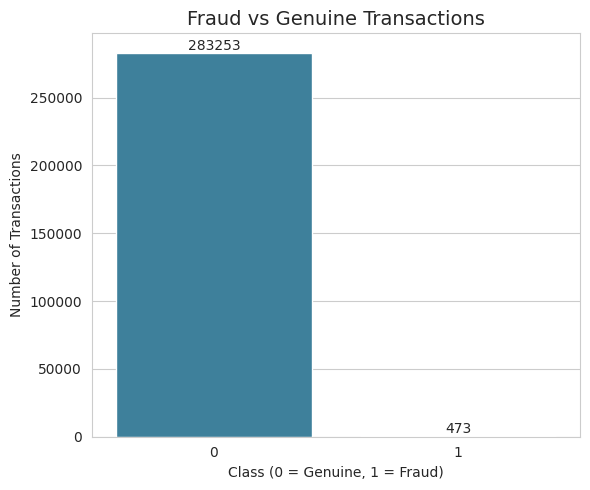

In [ ]:
plt.figure(figsize=(6, 5))
ax = sns.countplot(x="Class", data=df, palette=["#2E86AB", "#E63946"])
plt.title("Fraud vs Genuine Transactions", fontsize=14)
plt.xlabel("Class (0 = Genuine, 1 = Fraud)")
plt.ylabel("Number of Transactions")
for p in ax.patches:
    ax.annotate(f"{int(p.get_height())}", (p.get_x() + p.get_width() / 2, p.get_height()),
                ha="center", va="bottom", fontsize=10)
plt.tight_layout()
plt.show()

### 7.2 Transaction Amount Distribution

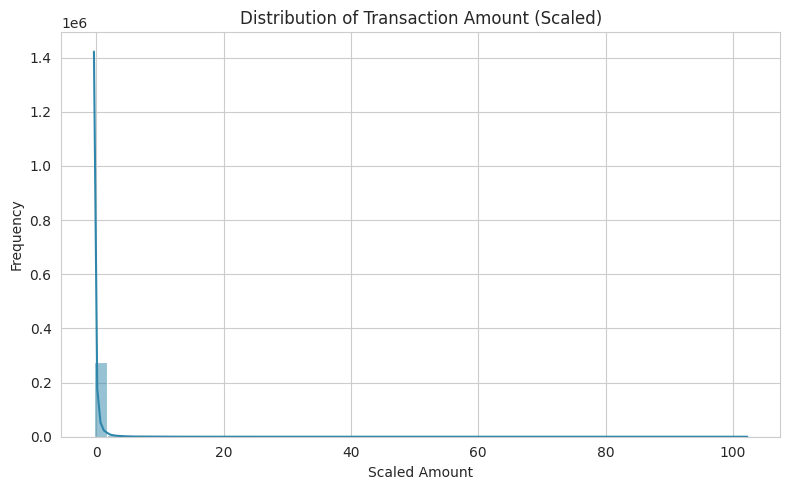

In [ ]:
plt.figure(figsize=(8, 5))
sns.histplot(df["scaled_amount"], bins=50, kde=True, color="#2E86AB")
plt.title("Distribution of Transaction Amount (Scaled)")
plt.xlabel("Scaled Amount")
plt.ylabel("Frequency")
plt.tight_layout()
plt.show()

### 7.3 Correlation Heatmap

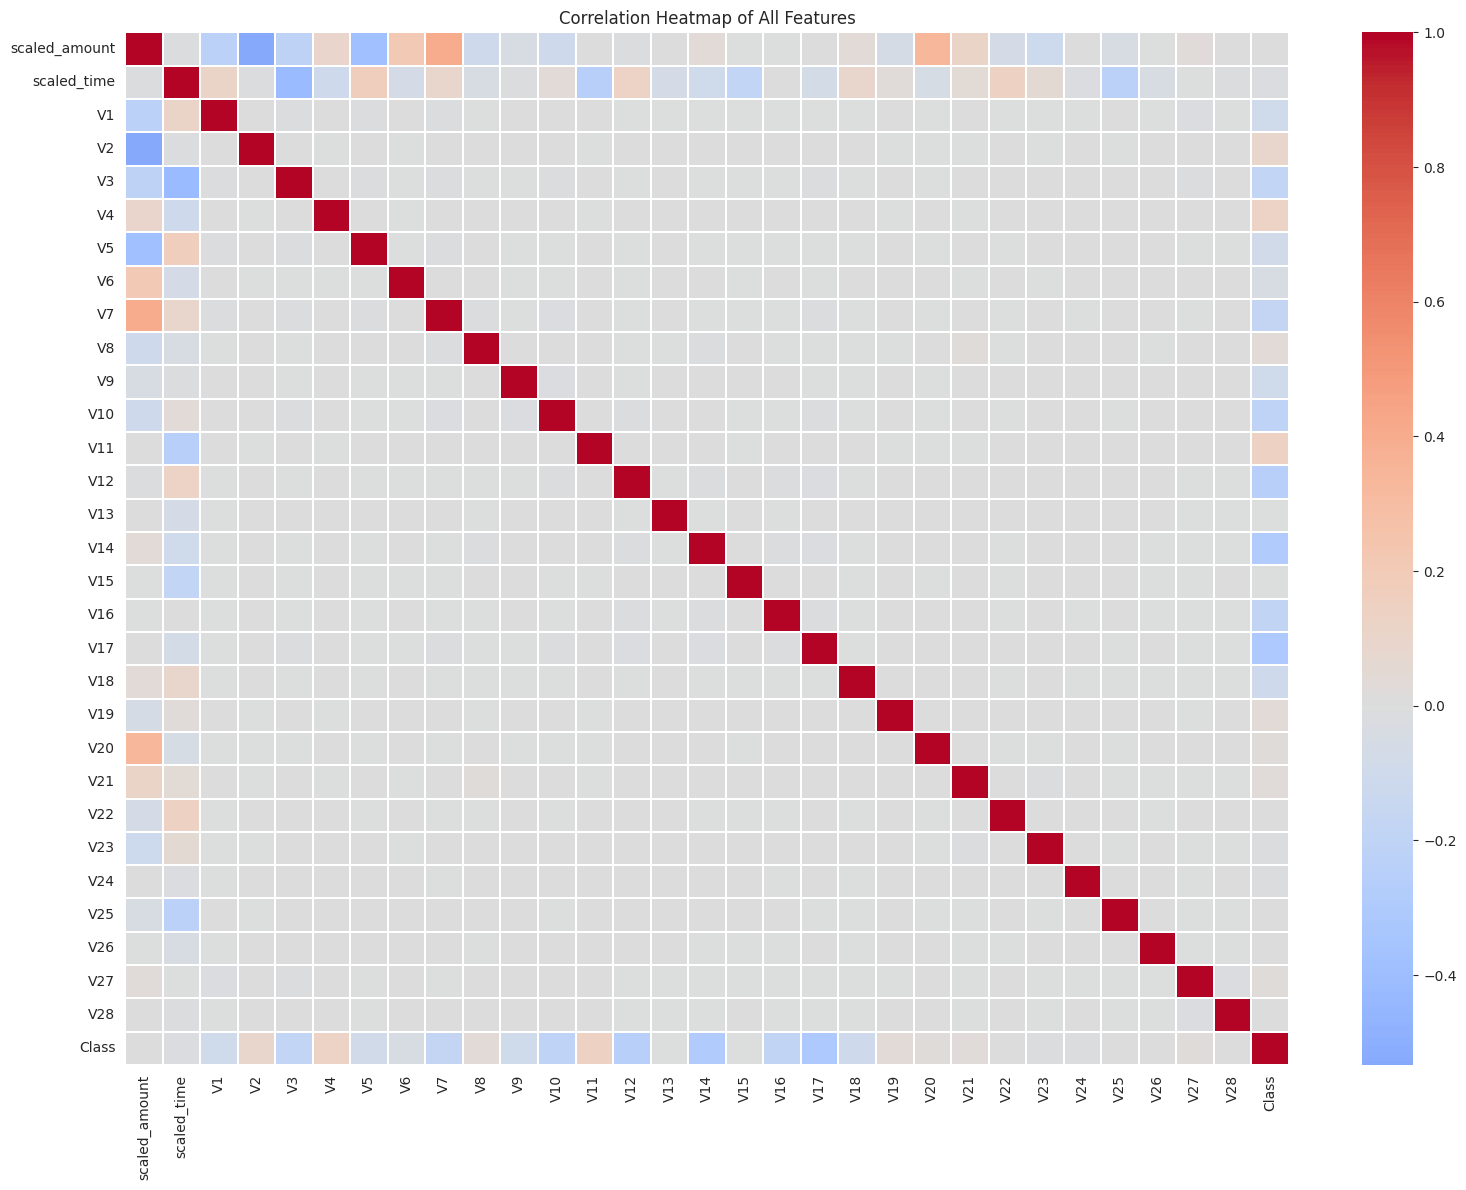

In [ ]:
plt.figure(figsize=(16, 12))
corr = df.corr()
sns.heatmap(corr, cmap="coolwarm", center=0, linewidths=0.2)
plt.title("Correlation Heatmap of All Features")
plt.tight_layout()
plt.show()

### 7.4 Histograms of Key Features

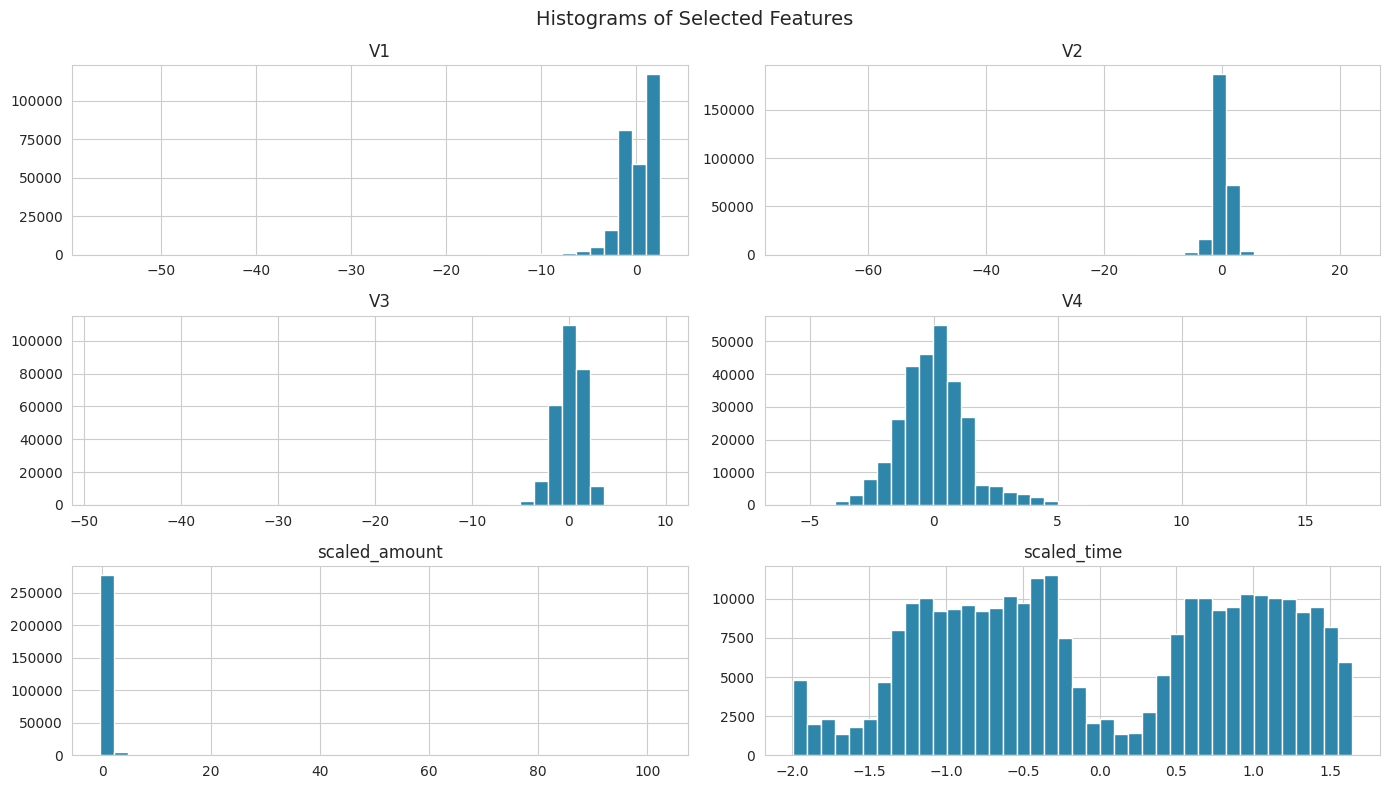

In [ ]:
features_to_plot = ["V1", "V2", "V3", "V4", "scaled_amount", "scaled_time"]

df[features_to_plot].hist(figsize=(14, 8), bins=40, color="#2E86AB")
plt.suptitle("Histograms of Selected Features", fontsize=14)
plt.tight_layout()
plt.show()

### 7.5 Box Plots (Fraud vs Genuine)

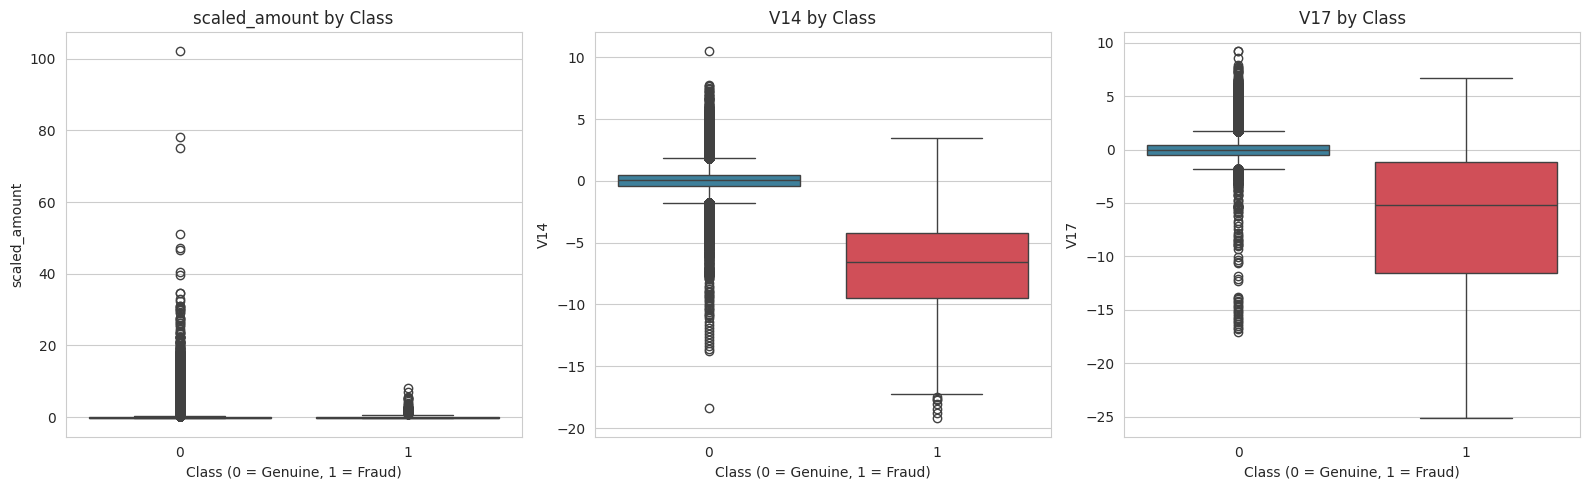

In [ ]:
fig, axes = plt.subplots(1, 3, figsize=(16, 5))

for ax, col in zip(axes, ["scaled_amount", "V14", "V17"]):
    sns.boxplot(x="Class", y=col, data=df, ax=ax, palette=["#2E86AB", "#E63946"])
    ax.set_title(f"{col} by Class")
    ax.set_xlabel("Class (0 = Genuine, 1 = Fraud)")

plt.tight_layout()
plt.show()

### 7.6 Pair Plot of a Few Important Features

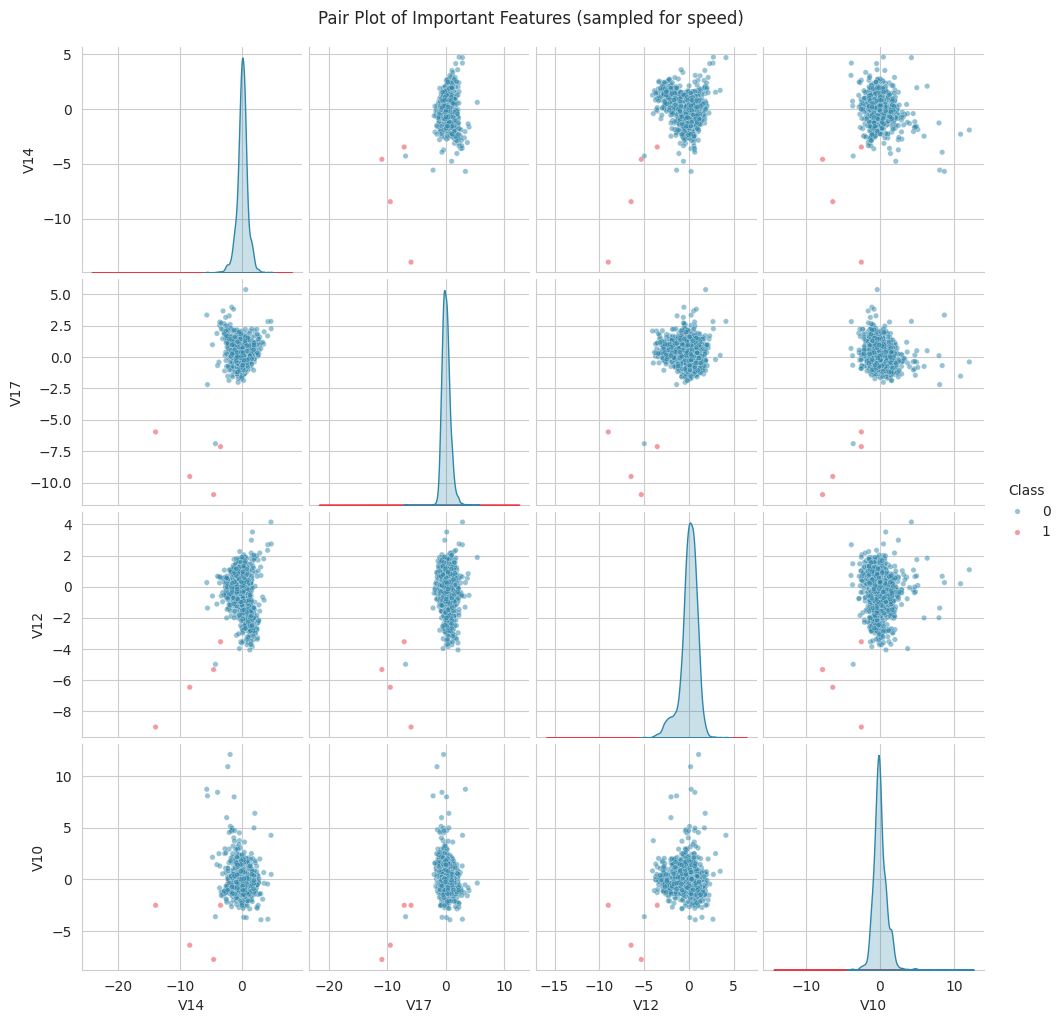

In [ ]:
sample_df = df.sample(n=3000, random_state=RANDOM_STATE)
sns.pairplot(sample_df[["V14", "V17", "V12", "V10", "Class"]], hue="Class",
             palette={0: "#2E86AB", 1: "#E63946"}, plot_kws={"alpha": 0.5, "s": 15})
plt.suptitle("Pair Plot of Important Features (sampled for speed)", y=1.02)
plt.show()

### 7.7 Distribution of Important Numerical Features (Fraud vs Genuine)

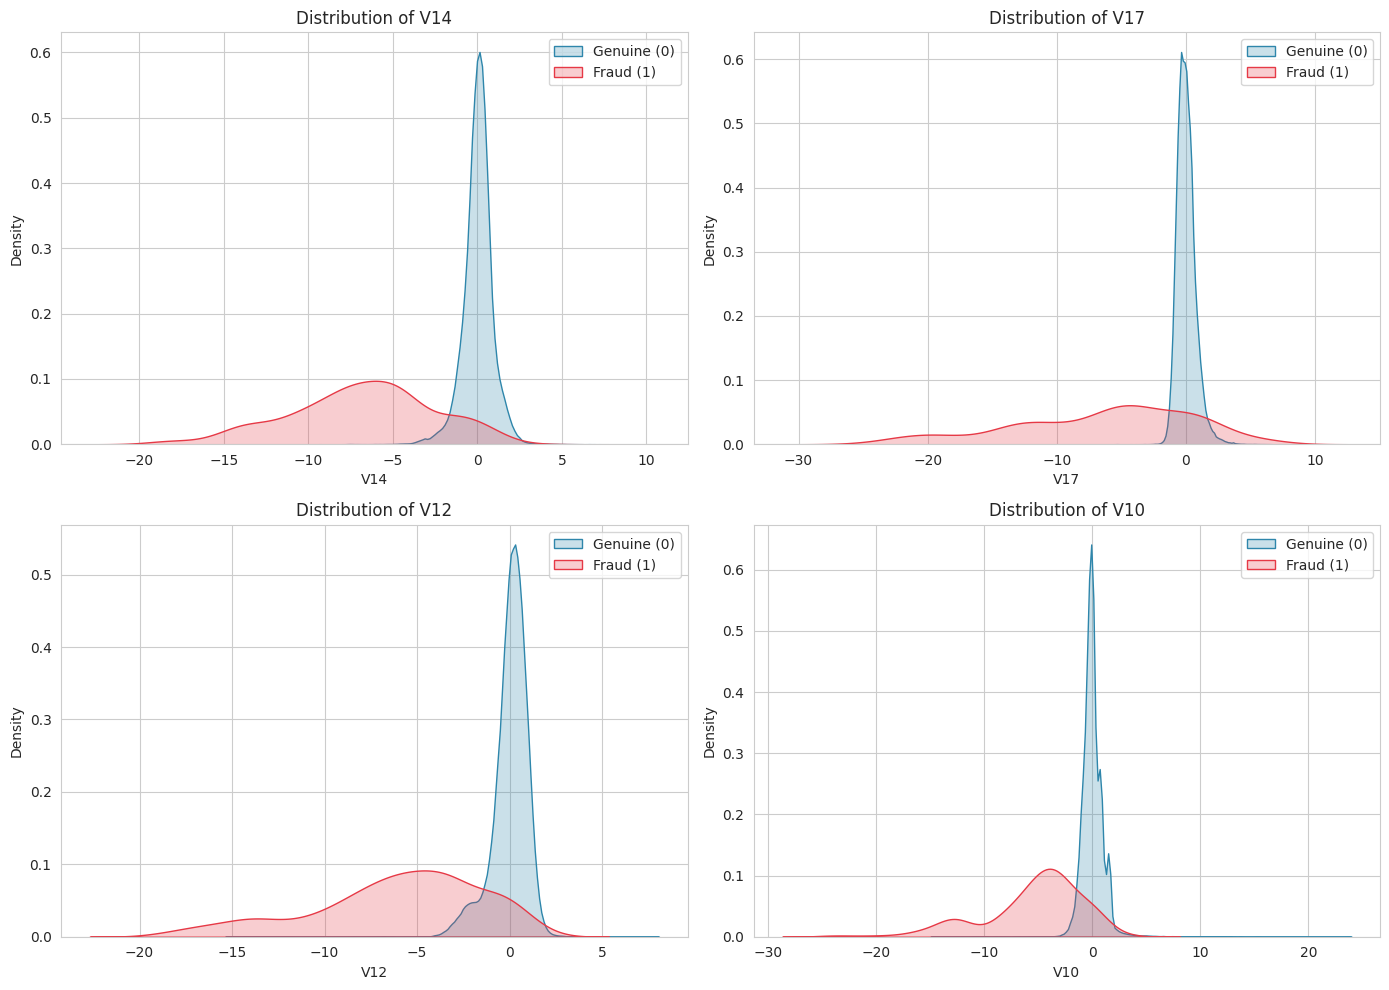

In [ ]:
important_features = ["V14", "V17", "V12", "V10"]

fig, axes = plt.subplots(2, 2, figsize=(14, 10))
axes = axes.flatten()

for ax, col in zip(axes, important_features):
    sns.kdeplot(df[df["Class"] == 0][col], label="Genuine (0)", ax=ax, color="#2E86AB", fill=True)
    sns.kdeplot(df[df["Class"] == 1][col], label="Fraud (1)", ax=ax, color="#E63946", fill=True)
    ax.set_title(f"Distribution of {col}")
    ax.legend()

plt.tight_layout()
plt.show()

## 8. Handle Class Imbalance




In [ ]:
print(df.shape)
print(df['Class'].isnull().sum())
print(df['Class'].unique())

(283726, 31)
0
[0 1]


In [ ]:
# Prepare features (X) and target (y) for the imbalance comparison
X_all = df.drop("Class", axis=1)
y_all = df["Class"]

# Split first, so resampling is only applied to training data
X_train_bal, X_test_bal, y_train_bal, y_test_bal = train_test_split(
    X_all, y_all, test_size=0.2, random_state=RANDOM_STATE, stratify=y_all
)

print("Original training class distribution:")
print(y_train_bal.value_counts())

Original training class distribution:
Class
0    226602
1       378
Name: count, dtype: int64


In [ ]:
# Random Oversampling
ros = RandomOverSampler(random_state=RANDOM_STATE)
X_over, y_over = ros.fit_resample(X_train_bal, y_train_bal)

# Random Undersampling
rus = RandomUnderSampler(random_state=RANDOM_STATE)
X_under, y_under = rus.fit_resample(X_train_bal, y_train_bal)

# SMOTE
smote = SMOTE(random_state=RANDOM_STATE)
X_smote, y_smote = smote.fit_resample(X_train_bal, y_train_bal)

print("Random Oversampling class distribution:")
print(y_over.value_counts())
print("\nRandom Undersampling class distribution:")
print(y_under.value_counts())
print("\nSMOTE class distribution:")
print(y_smote.value_counts())

Random Oversampling class distribution:
Class
0    226602
1    226602
Name: count, dtype: int64

Random Undersampling class distribution:
Class
0    378
1    378
Name: count, dtype: int64

SMOTE class distribution:
Class
0    226602
1    226602
Name: count, dtype: int64


In [ ]:
# Quick comparison: train a simple Logistic Regression on each version and compare Recall
resampling_results = {}

datasets = {
    "Original": (X_train_bal, y_train_bal),
    "Random Oversampling": (X_over, y_over),
    "Random Undersampling": (X_under, y_under),
    "SMOTE": (X_smote, y_smote),
}

for name, (X_res, y_res) in datasets.items():
    model = LogisticRegression(max_iter=1000, random_state=RANDOM_STATE)
    model.fit(X_res, y_res)
    preds = model.predict(X_test_bal)
    resampling_results[name] = {
        "Accuracy": accuracy_score(y_test_bal, preds),
        "Precision": precision_score(y_test_bal, preds),
        "Recall": recall_score(y_test_bal, preds),
        "F1 Score": f1_score(y_test_bal, preds),
    }

resampling_comparison = pd.DataFrame(resampling_results).T
resampling_comparison.round(4)

,Accuracy,Precision,Recall,F1 Score
Original,0.9991,0.8485,0.5895,0.6957
Random Oversampling,0.9754,0.0567,0.8737,0.1064
Random Undersampling,0.9731,0.0520,0.8737,0.0981
SMOTE,0.9737,0.0531,0.8737,0.1002


## 9. Feature Selection



In [ ]:
X = df.drop("Class", axis=1)
y = df["Class"]

print("Feature columns used for modelling:")
print(X.columns.tolist())
print(f"\nNumber of features: {X.shape[1]}")

Feature columns used for modelling:
['scaled_amount', 'scaled_time', 'V1', 'V2', 'V3', 'V4', 'V5', 'V6', 'V7', 'V8', 'V9', 'V10', 'V11', 'V12', 'V13', 'V14', 'V15', 'V16', 'V17', 'V18', 'V19', 'V20', 'V21', 'V22', 'V23', 'V24', 'V25', 'V26', 'V27', 'V28']

Number of features: 30


## 10. Split the Dataset into Training and Testing Sets



In [ ]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=RANDOM_STATE, stratify=y
)

print(f"Training set shape: {X_train.shape}")
print(f"Testing set shape: {X_test.shape}")
print("\nTraining set class distribution:")
print(y_train.value_counts())
print("\nTesting set class distribution:")
print(y_test.value_counts())

Training set shape: (226980, 30)
Testing set shape: (56746, 30)

Training set class distribution:
Class
0    226602
1       378
Name: count, dtype: int64

Testing set class distribution:
Class
0    56651
1       95
Name: count, dtype: int64


In [ ]:
smote_final = SMOTE(random_state=RANDOM_STATE)
X_train_smote, y_train_smote = smote_final.fit_resample(X_train, y_train)

print("Training class distribution after SMOTE:")
print(y_train_smote.value_counts())

Training class distribution after SMOTE:
Class
0    226602
1    226602
Name: count, dtype: int64


## 11. Train Multiple Classification Models



In [ ]:
# 1. Logistic Regression
log_reg = LogisticRegression(max_iter=1000, random_state=RANDOM_STATE)
log_reg.fit(X_train_smote, y_train_smote)
print("Logistic Regression trained.")

Logistic Regression trained.


In [ ]:
# 2. Decision Tree Classifier
dt_clf = DecisionTreeClassifier(max_depth=10, random_state=RANDOM_STATE)
dt_clf.fit(X_train_smote, y_train_smote)
print("Decision Tree Classifier trained.")

Decision Tree Classifier trained.


In [ ]:
# 3. Random Forest Classifier
rf_clf = RandomForestClassifier(
    n_estimators=100, max_depth=12, random_state=RANDOM_STATE, n_jobs=-1
)
rf_clf.fit(X_train_smote, y_train_smote)
print("Random Forest Classifier trained.")

Random Forest Classifier trained.


## 12. Compare Model Performance




In [ ]:
models = {
    "Logistic Regression": log_reg,
    "Decision Tree": dt_clf,
    "Random Forest": rf_clf,
}

results = {}
predictions = {}
probabilities = {}

for name, model in models.items():
    preds = model.predict(X_test)
    probs = model.predict_proba(X_test)[:, 1]

    predictions[name] = preds
    probabilities[name] = probs

    results[name] = {
        "Accuracy": accuracy_score(y_test, preds),
        "Precision": precision_score(y_test, preds),
        "Recall": recall_score(y_test, preds),
        "F1 Score": f1_score(y_test, preds),
        "ROC-AUC": roc_auc_score(y_test, probs),
    }

results_df = pd.DataFrame(results).T
results_df.round(4)

,Accuracy,Precision,Recall,F1 Score,ROC-AUC
Logistic Regression,0.9737,0.0531,0.8737,0.1002,0.9619
Decision Tree,0.9841,0.0773,0.7789,0.1407,0.8256
Random Forest,0.9990,0.6852,0.7789,0.7291,0.9787


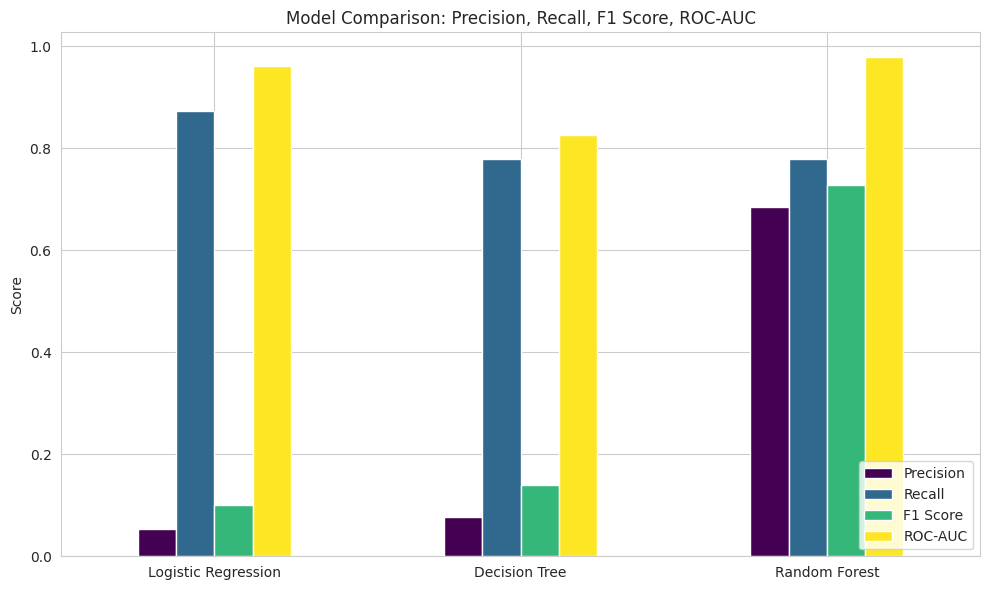

In [ ]:
results_df[["Precision", "Recall", "F1 Score", "ROC-AUC"]].plot(
    kind="bar", figsize=(10, 6), colormap="viridis"
)
plt.title("Model Comparison: Precision, Recall, F1 Score, ROC-AUC")
plt.ylabel("Score")
plt.xticks(rotation=0)
plt.legend(loc="lower right")
plt.tight_layout()
plt.show()

## 13. Confusion Matrix, Classification Report, and ROC Curve




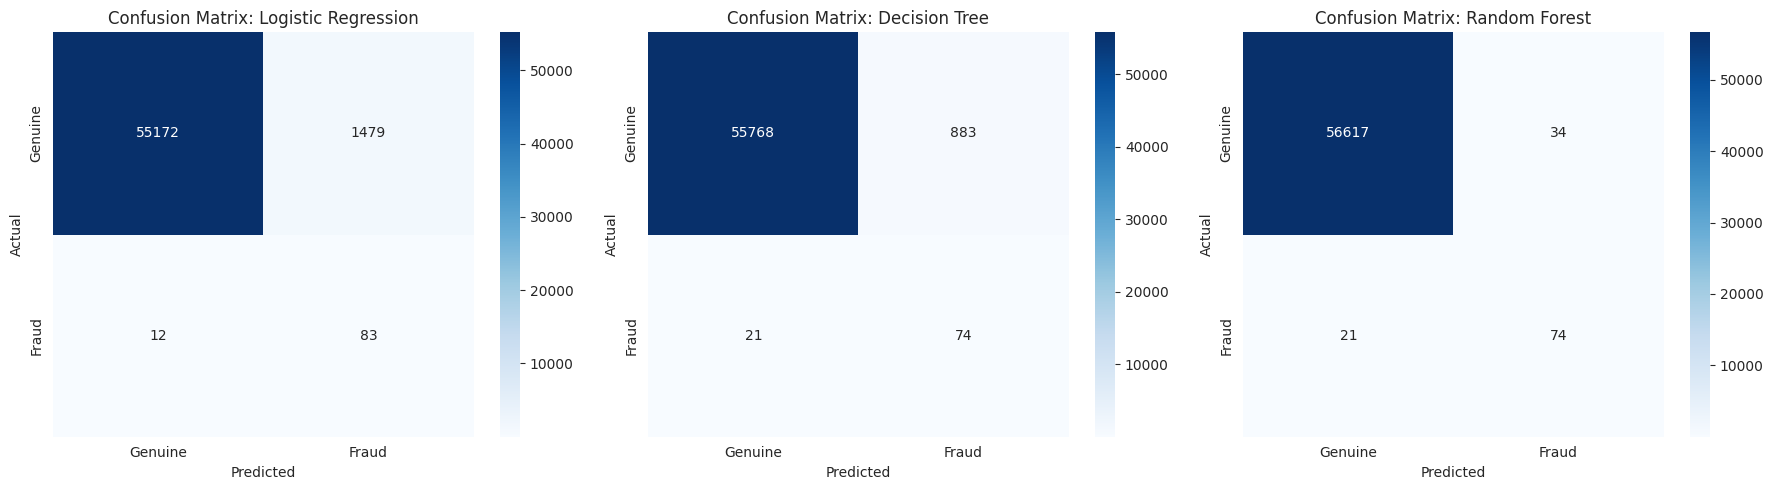

In [ ]:
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

for ax, (name, preds) in zip(axes, predictions.items()):
    cm = confusion_matrix(y_test, preds)
    sns.heatmap(cm, annot=True, fmt="d", cmap="Blues", ax=ax,
                xticklabels=["Genuine", "Fraud"], yticklabels=["Genuine", "Fraud"])
    ax.set_title(f"Confusion Matrix: {name}")
    ax.set_xlabel("Predicted")
    ax.set_ylabel("Actual")

plt.tight_layout()
plt.show()

In [ ]:
for name, preds in predictions.items():
    print(f"Classification Report: {name}")
    print(classification_report(y_test, preds, target_names=["Genuine", "Fraud"]))
    print("-" * 60)

Classification Report: Logistic Regression
              precision    recall  f1-score   support

     Genuine       1.00      0.97      0.99     56651
       Fraud       0.05      0.87      0.10        95

    accuracy                           0.97     56746
   macro avg       0.53      0.92      0.54     56746
weighted avg       1.00      0.97      0.99     56746

------------------------------------------------------------
Classification Report: Decision Tree
              precision    recall  f1-score   support

     Genuine       1.00      0.98      0.99     56651
       Fraud       0.08      0.78      0.14        95

    accuracy                           0.98     56746
   macro avg       0.54      0.88      0.57     56746
weighted avg       1.00      0.98      0.99     56746

------------------------------------------------------------
Classification Report: Random Forest
              precision    recall  f1-score   support

     Genuine       1.00      1.00      1.00     5665

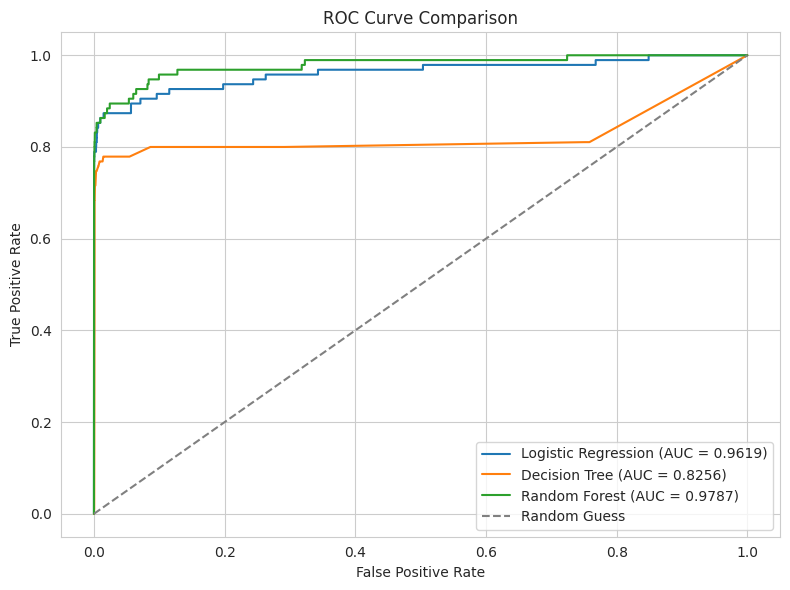

In [ ]:
plt.figure(figsize=(8, 6))

for name, probs in probabilities.items():
    fpr, tpr, _ = roc_curve(y_test, probs)
    auc_score = roc_auc_score(y_test, probs)
    plt.plot(fpr, tpr, label=f"{name} (AUC = {auc_score:.4f})")

plt.plot([0, 1], [0, 1], linestyle="--", color="gray", label="Random Guess")
plt.title("ROC Curve Comparison")
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.legend(loc="lower right")
plt.tight_layout()
plt.show()

## 14. Compare All Models and Select the Best-Performing One




In [ ]:
best_model_name = results_df["F1 Score"].idxmax()
print(f"Best performing model (based on F1 Score): {best_model_name}")
print("\nPerformance summary:")
results_df.loc[[best_model_name]].round(4)

Best performing model (based on F1 Score): Random Forest

Performance summary:


,Accuracy,Precision,Recall,F1 Score,ROC-AUC
Random Forest,0.999,0.6852,0.7789,0.7291,0.9787


In [ ]:
best_model = models[best_model_name]
print(f"Selected final model for deployment-ready use: {best_model_name}")

Selected final model for deployment-ready use: Random Forest


## 15. Feature Importance




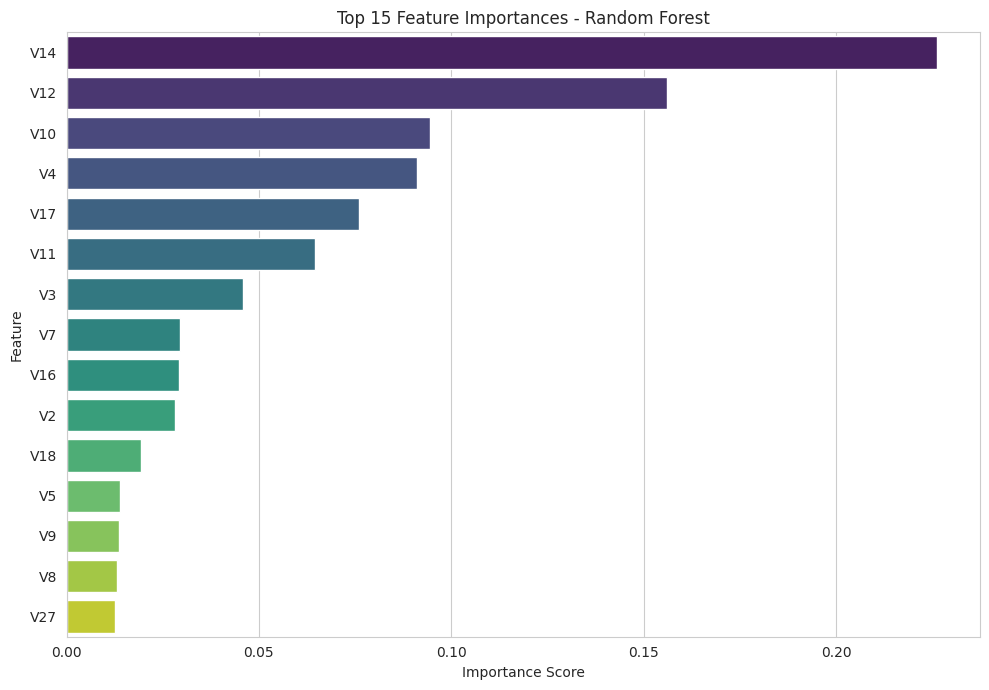

In [ ]:
if hasattr(best_model, "feature_importances_"):
    importances = pd.Series(best_model.feature_importances_, index=X.columns)
    importances = importances.sort_values(ascending=False).head(15)

    plt.figure(figsize=(10, 7))
    sns.barplot(x=importances.values, y=importances.index, palette="viridis")
    plt.title(f"Top 15 Feature Importances - {best_model_name}")
    plt.xlabel("Importance Score")
    plt.ylabel("Feature")
    plt.tight_layout()
    plt.show()
else:
    print(f"{best_model_name} does not support feature_importances_ (e.g. Logistic Regression).")
    print("For linear models, feature importance can instead be inspected via model coefficients.")

## 16. Predict Whether Unseen Transactions Are Fraudulent or Genuine



In [ ]:
# Simulate a small batch of unseen/new transactions
unseen_transactions = X_test.sample(n=10, random_state=RANDOM_STATE)

unseen_predictions = best_model.predict(unseen_transactions)
unseen_probabilities = best_model.predict_proba(unseen_transactions)[:, 1]

unseen_results = unseen_transactions.copy()
unseen_results["Predicted_Class"] = unseen_predictions
unseen_results["Predicted_Label"] = unseen_results["Predicted_Class"].map(
    {0: "Genuine", 1: "Fraud"}
)
unseen_results["Fraud_Probability"] = unseen_probabilities.round(4)

unseen_results[["scaled_amount", "Predicted_Class", "Predicted_Label", "Fraud_Probability"]]

,scaled_amount,Predicted_Class,Predicted_Label,Fraud_Probability
31580,0.302467,0,Genuine,0.0029
65974,-0.313431,0,Genuine,0.0035
268368,2.008823,0,Genuine,0.0319
144177,-0.317424,0,Genuine,0.0150
6323,-0.323055,0,Genuine,0.1990
279097,-0.173614,0,Genuine,0.0495
164997,1.307782,0,Genuine,0.0269
97193,-0.134875,0,Genuine,0.0238
132753,-0.349333,0,Genuine,0.1538
6270,-0.329285,0,Genuine,0.0462


## 17. Save the Trained Model




In [ ]:
model_filename = "fraud_detection_model.pkl"
joblib.dump(best_model, model_filename)
print(f"Model saved successfully as '{model_filename}'")

# Also save the scaler used for preprocessing, so new raw data can be scaled consistently
joblib.dump(scaler, "scaler.pkl")
print("Scaler saved successfully as 'scaler.pkl'")

Model saved successfully as 'fraud_detection_model.pkl'
Scaler saved successfully as 'scaler.pkl'


## 18. Save the Prediction Results into a CSV File



In [ ]:
final_predictions = best_model.predict(X_test)
final_probabilities = best_model.predict_proba(X_test)[:, 1]

prediction_output = X_test.copy()
prediction_output["Actual_Class"] = y_test.values
prediction_output["Predicted_Class"] = final_predictions
prediction_output["Fraud_Probability"] = final_probabilities.round(4)

prediction_output.to_csv("fraud_detection_predictions.csv", index=False)

print("Predictions saved successfully to 'fraud_detection_predictions.csv'")
print(f"Total predictions saved: {len(prediction_output)}")
prediction_output.head()

Predictions saved successfully to 'fraud_detection_predictions.csv'
Total predictions saved: 56746


,scaled_amount,scaled_time,V1,V2,V3,V4,V5,V6,V7,V8,...,V22,V23,V24,V25,V26,V27,V28,Actual_Class,Predicted_Class,Fraud_Probability
86568,-0.307400,-0.705990,1.228821,-0.063408,0.274145,0.647465,-0.048135,0.372073,-0.224231,0.079939,...,-0.083779,-0.151661,-0.700372,0.598550,0.491409,0.002989,0.001782,0,0,0.0056
251557,-0.345579,1.275941,-0.203154,1.176678,-0.759595,-0.518472,0.629649,-0.721675,0.638893,0.243377,...,1.206754,-0.082753,0.508386,-0.710906,-0.234510,0.379640,0.261351,0,0,0.0090
20232,0.011211,-1.346436,-1.672836,1.401297,1.503940,2.175491,0.699791,1.062139,1.114364,-0.535822,...,-0.408743,-0.280083,-0.846468,-0.155456,-0.062383,0.007777,0.113900,0,0,0.0658
68952,0.557220,-0.876311,0.819379,-1.124913,0.515025,0.513945,-1.009048,0.488484,-0.580672,0.187686,...,-0.168061,-0.198732,-0.337408,0.238538,-0.289454,0.038214,0.058407,0,0,0.0088
191852,-0.347696,0.729091,2.009701,0.105635,-1.752759,0.588312,0.374801,-0.637884,0.009260,-0.129487,...,0.357394,-0.013472,-0.446920,0.111522,0.642944,-0.036998,-0.043404,0,0,0.0992
